# Cross-Dataset Analysis: Frozen vs Learned Text Projection

**Forschungsfrage:** *Warum funktioniert eine gefrorene, zufällig initialisierte Text-Projektion besser als eine gelernte?*

Dieses Notebook konsolidiert die Ergebnisse aus 4 Datensätzen:

| Dataset | Task | Metric | n_train | n_tasks |
|---------|------|--------|---------|---------|
| ESOL | Regression | RMSE ↓ | 902 | 1 |
| BACE | Classification | AUC-ROC ↑ | 1210 | 1 |
| Tox21 | Multi-Label Classification | Mean AUC ↑ | 6258 | 12 |
| QM8 | Multi-Task Regression | Mean MAE ↓ | 17397 | 16 |

Alle Daten stammen aus `benchmarking/results/*_analysis.json` (Export der Einzel-Notebooks).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8,
})

RESULTS_DIR = Path("results")
DATASETS = ["esol", "bace", "tox21", "qm8"]
DATASET_LABELS = {"esol": "ESOL", "bace": "BACE", "tox21": "Tox21", "qm8": "QM8"}

data = {}
for name in DATASETS:
    with open(RESULTS_DIR / f"{name}_analysis.json") as f:
        data[name] = json.load(f)

print("Loaded datasets:")
for name, d in data.items():
    print(f"  {DATASET_LABELS[name]:>5}: n_train={d['n_train']:>5}, "
          f"metric={d['primary_metric']}, "
          f"configs={list(d['seg_results'].keys())}")

Loaded datasets:
   ESOL: n_train=  902, metric=rmse, configs=['xavier_frozen', 'xavier_learned', 'kaiming_frozen', 'kaiming_learned']
   BACE: n_train= 1210, metric=roc_auc, configs=['xavier_frozen', 'xavier_learned', 'kaiming_frozen', 'kaiming_learned']
  Tox21: n_train= 6258, metric=mean_auc, configs=['xavier_frozen', 'xavier_learned']
    QM8: n_train=17397, metric=mean_mae, configs=['xavier_frozen', 'xavier_learned']


---
## 1. Frozen vs Learned: Haupteffekt über alle Datensätze

Normalisierter Vergleich: Wie viel besser/schlechter ist frozen gegenüber learned, relativ zum Leistungsniveau?

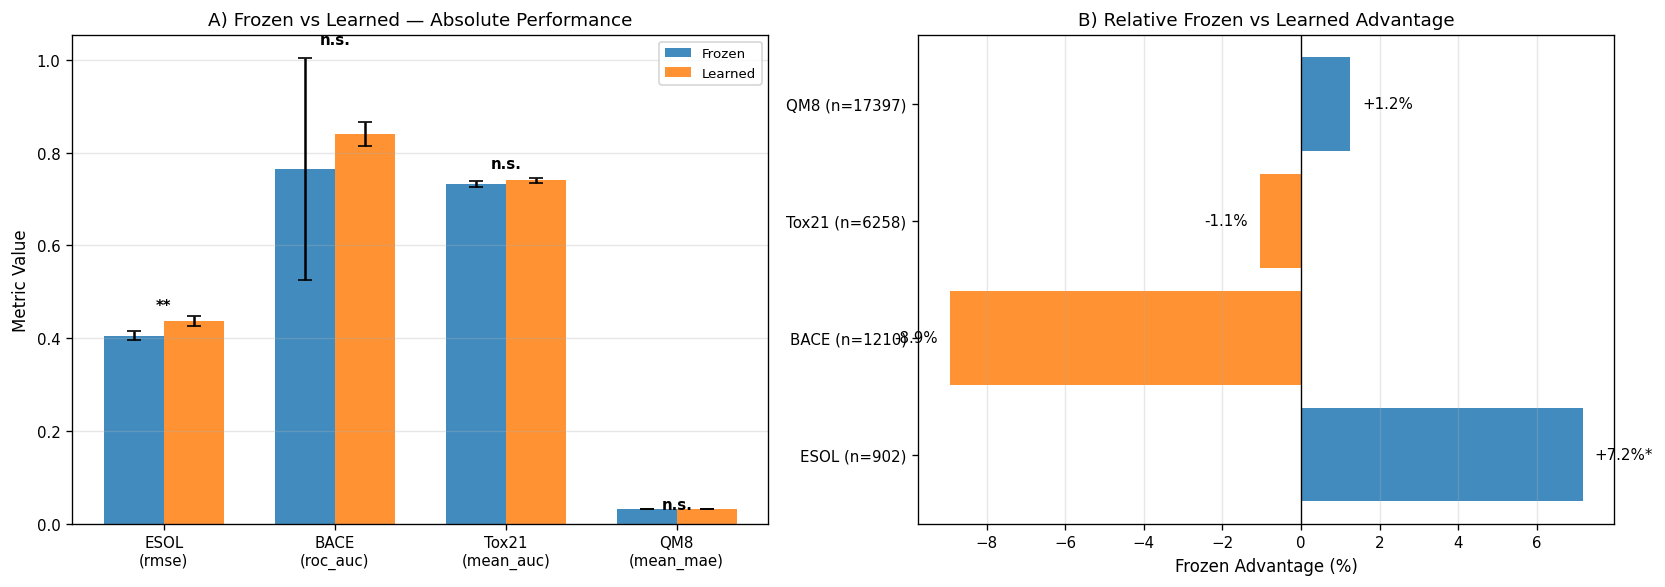


=== Frozen vs Learned (xavier) — Paired t-test ===
Dataset  Metric                 Frozen            Learned        p   Winner
--------------------------------------------------------------------------
ESOL     rmse       0.4056±0.0093 0.4369±0.0107  0.0032  frozen*
BACE     roc_auc    0.7645±0.2389 0.8395±0.0262  0.5256 learned
Tox21    mean_auc   0.7321±0.0070 0.7399±0.0052  0.3245 learned
QM8      mean_mae   0.0308±0.0000 0.0312±0.0001  0.1846  frozen


In [2]:
# === Frozen vs Learned: Relative Performance ===

def get_seg_metric_values(d, config_name):
    """Extract per-seed metric values for a given config."""
    metric = d["primary_metric"]
    seeds = d["seg_results"].get(config_name, {})
    return [s["metrics"][metric] for s in seeds.values()]

# Collect frozen vs learned for xavier (available in all datasets)
comparison_rows = []
for name in DATASETS:
    d = data[name]
    metric = d["primary_metric"]
    higher_better = d["task_type"] in ("classification", "multi_label_classification")
    
    frozen_vals = get_seg_metric_values(d, "xavier_frozen")
    learned_vals = get_seg_metric_values(d, "xavier_learned")
    
    # Paired t-test (same seeds)
    t_stat, p_val = stats.ttest_rel(frozen_vals[:len(learned_vals)],
                                     learned_vals[:len(frozen_vals)])
    
    comparison_rows.append({
        "dataset": DATASET_LABELS[name],
        "n_train": d["n_train"],
        "metric": metric,
        "higher_better": higher_better,
        "frozen_mean": np.mean(frozen_vals),
        "frozen_std": np.std(frozen_vals),
        "learned_mean": np.mean(learned_vals),
        "learned_std": np.std(learned_vals),
        "n_seeds": min(len(frozen_vals), len(learned_vals)),
        "p_value": p_val,
        "frozen_wins": (np.mean(frozen_vals) < np.mean(learned_vals)) if not higher_better
                       else (np.mean(frozen_vals) > np.mean(learned_vals)),
    })

comp_df = pd.DataFrame(comparison_rows)

# --- Figure: 2-panel ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Absolute performance per dataset
ax = axes[0]
x = np.arange(len(comp_df))
w = 0.35
bars_f = ax.bar(x - w/2, comp_df["frozen_mean"], w, yerr=comp_df["frozen_std"],
                label="Frozen", color="tab:blue", alpha=0.85, capsize=4)
bars_l = ax.bar(x + w/2, comp_df["learned_mean"], w, yerr=comp_df["learned_std"],
                label="Learned", color="tab:orange", alpha=0.85, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels([f"{r['dataset']}\n({r['metric']})" for _, r in comp_df.iterrows()])
ax.set_ylabel("Metric Value")
ax.set_title("A) Frozen vs Learned — Absolute Performance")
ax.legend()
ax.grid(alpha=0.3, axis="y")

# Add significance stars
for i, row in comp_df.iterrows():
    top = max(row["frozen_mean"] + row["frozen_std"],
              row["learned_mean"] + row["learned_std"])
    star = "***" if row["p_value"] < 0.001 else "**" if row["p_value"] < 0.01 \
           else "*" if row["p_value"] < 0.05 else "n.s."
    ax.text(i, top * 1.03, star, ha="center", fontsize=9, fontweight="bold")

# Panel B: Normalized advantage (frozen - learned, sign-corrected so positive = frozen better)
ax = axes[1]
deltas = []
for _, row in comp_df.iterrows():
    if row["higher_better"]:
        # AUC: higher is better → frozen advantage = frozen - learned
        delta_pct = (row["frozen_mean"] - row["learned_mean"]) / row["learned_mean"] * 100
    else:
        # RMSE/MAE: lower is better → frozen advantage = learned - frozen (positive = frozen better)
        delta_pct = (row["learned_mean"] - row["frozen_mean"]) / row["learned_mean"] * 100
    deltas.append(delta_pct)

colors_bar = ["tab:blue" if d > 0 else "tab:orange" for d in deltas]
ax.barh(x, deltas, color=colors_bar, alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels([f"{r['dataset']} (n={r['n_train']})" for _, r in comp_df.iterrows()])
ax.set_xlabel("Frozen Advantage (%)")
ax.set_title("B) Relative Frozen vs Learned Advantage")
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(alpha=0.3, axis="x")

for i, (d, row) in enumerate(zip(deltas, comp_df.itertuples())):
    sign = "+" if d > 0 else ""
    star = "*" if row.p_value < 0.05 else ""
    ax.text(d + (0.3 if d >= 0 else -0.3), i,
            f"{sign}{d:.1f}%{star}", va="center",
            ha="left" if d >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

# Summary table
print("\n=== Frozen vs Learned (xavier) — Paired t-test ===")
print(f"{'Dataset':<8} {'Metric':<10} {'Frozen':>18} {'Learned':>18} {'p':>8} {'Winner':>8}")
print("-" * 74)
for _, r in comp_df.iterrows():
    winner = "frozen" if r["frozen_wins"] else "learned"
    sig = "*" if r["p_value"] < 0.05 else ""
    print(f"{r['dataset']:<8} {r['metric']:<10} "
          f"{r['frozen_mean']:.4f}±{r['frozen_std']:.4f} "
          f"{r['learned_mean']:.4f}±{r['learned_std']:.4f} "
          f"{r['p_value']:>7.4f} {winner:>7}{sig}")

---
## 2. Bias-Variance-Tradeoff: Datensatzgröße als Moderator

**Hypothese:** Frozen gewinnt bei kleinen Datensätzen (Regularisierung > Information), learned gewinnt bei großen (genug Daten um Überanpassung zu vermeiden).

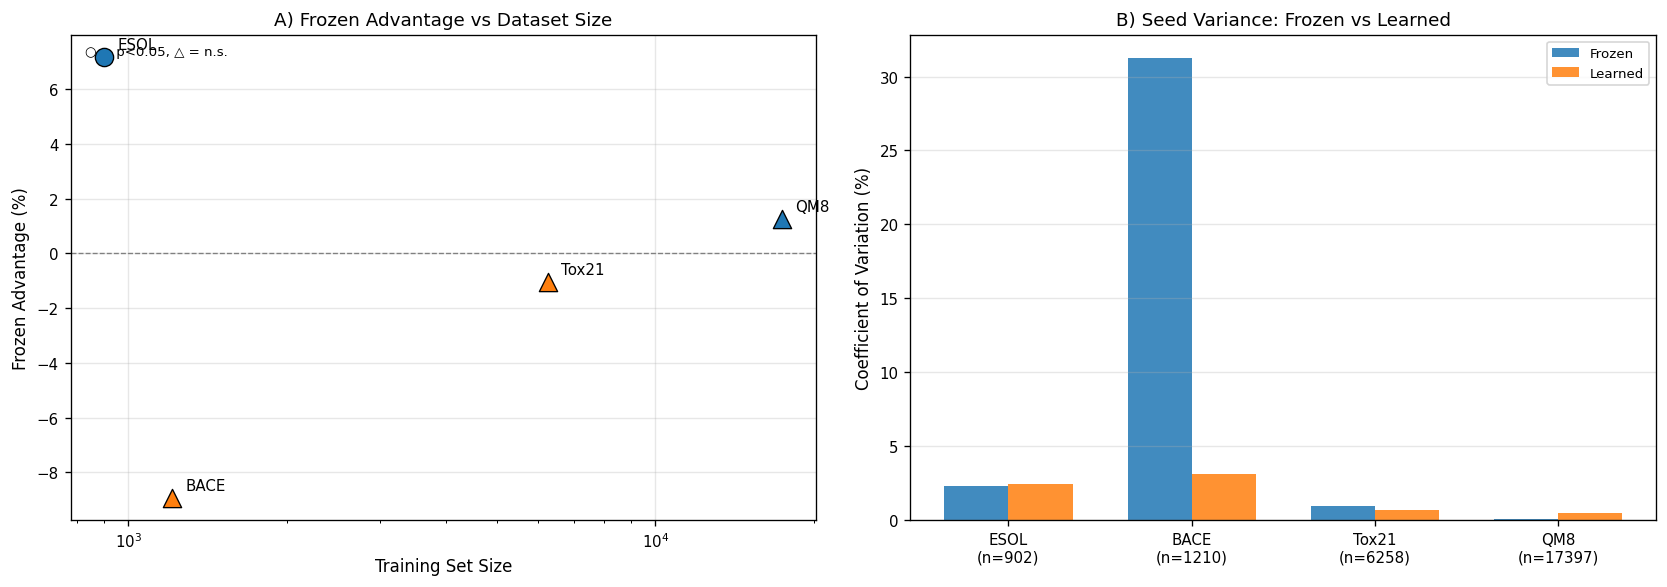


Spearman ρ(n_train, frozen_advantage) = -0.200 (p=0.800)
→ Frozen advantage decreases with dataset size

=== Detailanalyse ===
   ESOL (n=  902): Frozen Advantage = +7.17% (signifikant)
   BACE (n= 1210): Frozen Advantage = -8.93% (nicht signifikant)
  Tox21 (n= 6258): Frozen Advantage = -1.06% (nicht signifikant)
    QM8 (n=17397): Frozen Advantage = +1.25% (nicht signifikant)

=== Varianz-Analyse (CV%) ===
Dataset    Frozen CV%  Learned CV%   Mehr Varianz
--------------------------------------------------
ESOL             2.30         2.44        Learned
BACE            31.25         3.12         Frozen
Tox21            0.96         0.71         Frozen
QM8              0.07         0.45        Learned

Höherer CV% = weniger stabil über Seeds → mehr Varianz-Komponente im Fehler.


In [3]:
# === Dataset Size vs Frozen Advantage ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Frozen advantage vs dataset size
ax = axes[0]
n_trains = comp_df["n_train"].values
deltas_arr = np.array(deltas)

for i, (_, row) in enumerate(comp_df.iterrows()):
    color = "tab:blue" if deltas[i] > 0 else "tab:orange"
    marker = "o" if row["p_value"] < 0.05 else "^"
    ax.scatter(row["n_train"], deltas[i], s=120, c=color, marker=marker,
              edgecolors="black", linewidth=0.8, zorder=5)
    ax.annotate(row["dataset"], (row["n_train"], deltas[i]),
               textcoords="offset points", xytext=(8, 5), fontsize=9)

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Frozen Advantage (%)")
ax.set_title("A) Frozen Advantage vs Dataset Size")
ax.set_xscale("log")
ax.grid(alpha=0.3)
ax.text(0.02, 0.98, "○ = p<0.05, △ = n.s.", transform=ax.transAxes,
        fontsize=8, va="top")

# Panel B: Variance comparison (std of metric across seeds)
ax = axes[1]
variance_data = []
for name in DATASETS:
    d = data[name]
    metric = d["primary_metric"]
    for config in ["xavier_frozen", "xavier_learned"]:
        vals = get_seg_metric_values(d, config)
        label = "frozen" if "frozen" in config else "learned"
        variance_data.append({
            "dataset": DATASET_LABELS[name],
            "n_train": d["n_train"],
            "config": label,
            "std": np.std(vals),
            "cv": np.std(vals) / (np.mean(vals) + 1e-10) * 100,  # CV%
        })

var_df = pd.DataFrame(variance_data)

x = np.arange(len(DATASETS))
w = 0.35
frozen_cv = var_df[var_df["config"] == "frozen"]["cv"].values
learned_cv = var_df[var_df["config"] == "learned"]["cv"].values
ax.bar(x - w/2, frozen_cv, w, label="Frozen", color="tab:blue", alpha=0.85)
ax.bar(x + w/2, learned_cv, w, label="Learned", color="tab:orange", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"{DATASET_LABELS[n]}\n(n={data[n]['n_train']})" for n in DATASETS])
ax.set_ylabel("Coefficient of Variation (%)")
ax.set_title("B) Seed Variance: Frozen vs Learned")
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Spearman correlation: dataset size vs frozen advantage
rho, p = stats.spearmanr(n_trains, deltas_arr)
print(f"\nSpearman ρ(n_train, frozen_advantage) = {rho:.3f} (p={p:.3f})")
print("→", "Frozen advantage decreases with dataset size" if rho < 0 else
      "No clear trend")

print("\n=== Detailanalyse ===")
for i, (_, row) in enumerate(comp_df.iterrows()):
    sign = "+" if deltas[i] > 0 else ""
    sig = " (signifikant)" if row["p_value"] < 0.05 else " (nicht signifikant)"
    print(f"  {row['dataset']:>5} (n={row['n_train']:>5}): Frozen Advantage = {sign}{deltas[i]:.2f}%{sig}")

print(f"\n=== Varianz-Analyse (CV%) ===")
print(f"{'Dataset':<8} {'Frozen CV%':>12} {'Learned CV%':>12} {'Mehr Varianz':>14}")
print("-" * 50)
for i, name in enumerate(DATASETS):
    f_cv = frozen_cv[i]
    l_cv = learned_cv[i]
    more = "Learned" if l_cv > f_cv else "Frozen"
    print(f"{DATASET_LABELS[name]:<8} {f_cv:>12.2f} {l_cv:>12.2f} {more:>14}")
print("\nHöherer CV% = weniger stabil über Seeds → mehr Varianz-Komponente im Fehler.")

---
## 3. Baselines: Relative Stärke der Modellkomponenten

Wo steht SEG im Vergleich zu den Einzel-Komponenten (RF, ChebNet, TextMLP)?

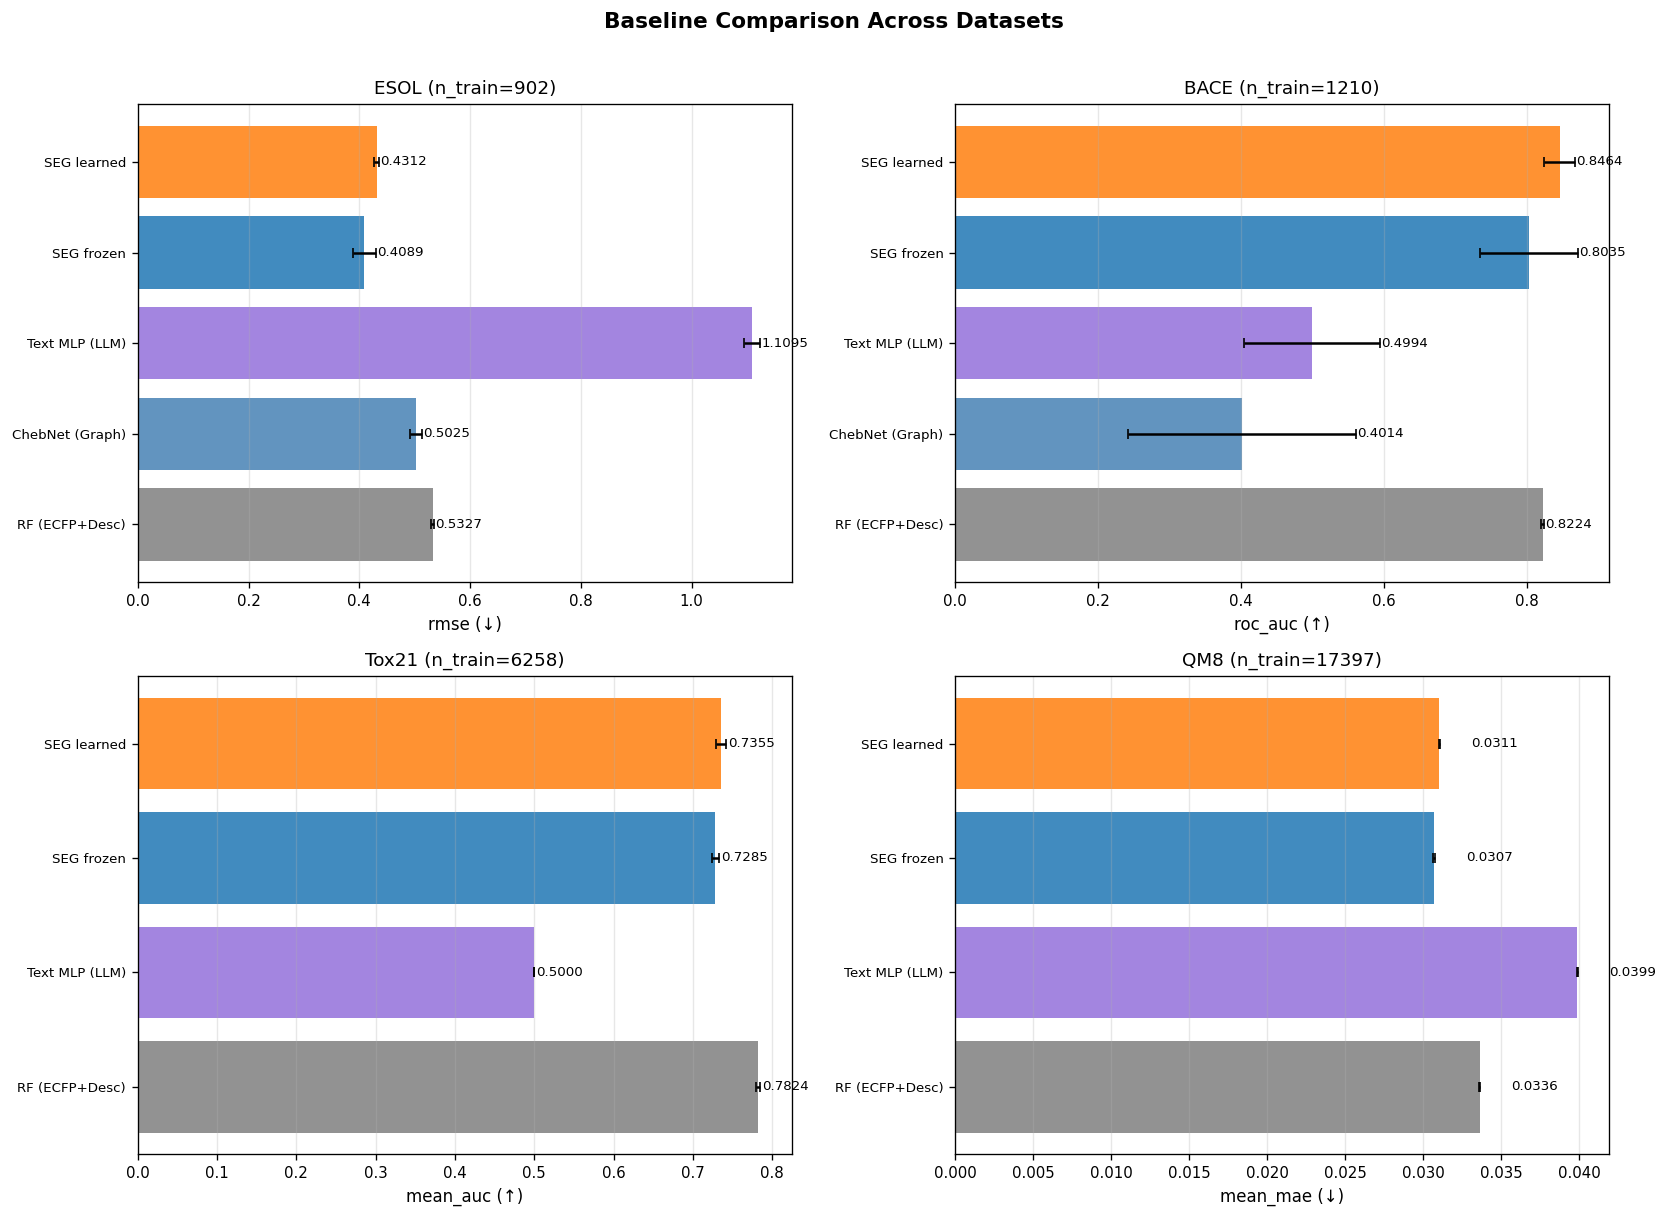


=== Baseline Performance Ranking ===

--- ESOL (rmse, ↓, n_train=902) ---
  1. SEG frozen: 0.4089
  2. SEG learned: 0.4312
  3. ChebNet (Graph): 0.5025
  4. RF (ECFP+Desc): 0.5327
  5. Text MLP (LLM): 1.1095
  → SEG WINS: SEG frozen=0.4089 vs RF=0.5327 (+23.2%)

--- BACE (roc_auc, ↑, n_train=1210) ---
  1. SEG learned: 0.8464
  2. RF (ECFP+Desc): 0.8224
  3. SEG frozen: 0.8035
  4. Text MLP (LLM): 0.4994
  5. ChebNet (Graph): 0.4014
  → SEG WINS: SEG learned=0.8464 vs RF=0.8224 (+2.9%)

--- Tox21 (mean_auc, ↑, n_train=6258) ---
  1. RF (ECFP+Desc): 0.7824
  2. SEG learned: 0.7355
  3. SEG frozen: 0.7285
  4. Text MLP (LLM): 0.5000
  → RF WINS: SEG learned=0.7355 vs RF=0.7824 (-6.0%)

--- QM8 (mean_mae, ↓, n_train=17397) ---
  1. SEG frozen: 0.0307
  2. SEG learned: 0.0311
  3. RF (ECFP+Desc): 0.0336
  4. Text MLP (LLM): 0.0399
  → SEG WINS: SEG frozen=0.0307 vs RF=0.0336 (+8.7%)


=== SEG (all seeds, xavier) vs RF — Vollständiger Vergleich ===
(seg_results enthält alle Seeds, baseline

In [4]:
# === Cross-Dataset Baseline Comparison ===

def shorten_baseline_name(name):
    """Create readable short names preserving SEG frozen/learned distinction."""
    if "SEG" in name and "frozen" in name:
        return "SEG frozen"
    elif "SEG" in name and "learned" in name:
        return "SEG learned"
    elif "Random Forest" in name:
        return "RF (ECFP+Desc)"
    elif "ChebNet" in name:
        return "ChebNet (Graph)"
    elif "Text MLP" in name:
        return "Text MLP (LLM)"
    return name

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, name in enumerate(DATASETS):
    ax = axes[idx // 2, idx % 2]
    d = data[name]
    metric = d["primary_metric"]
    higher_better = d["task_type"] in ("classification", "multi_label_classification")

    # Collect baselines
    models = {}
    for bname, bdata in d["baselines"].items():
        short = shorten_baseline_name(bname)
        models[short] = {"mean": bdata["mean"], "std": bdata["std"], "n": bdata["n"]}

    # Plot
    names_list = list(models.keys())
    means = [m["mean"] for m in models.values()]
    stds = [m["std"] for m in models.values()]

    # Color-code by model type
    color_map = []
    for n in names_list:
        if "frozen" in n.lower():
            color_map.append("tab:blue")
        elif "learned" in n.lower():
            color_map.append("tab:orange")
        elif "text" in n.lower():
            color_map.append("mediumpurple")
        elif "cheb" in n.lower():
            color_map.append("steelblue")
        else:
            color_map.append("#7f7f7f")

    bars = ax.barh(range(len(names_list)), means, xerr=stds, capsize=3,
                   color=color_map, alpha=0.85)
    ax.set_yticks(range(len(names_list)))
    ax.set_yticklabels(names_list, fontsize=8)
    ax.set_xlabel(f"{metric} ({'↑' if higher_better else '↓'})")
    ax.set_title(f"{DATASET_LABELS[name]} (n_train={d['n_train']})")
    ax.grid(alpha=0.3, axis="x")

    # Value labels
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(m + s + 0.002, i, f"{m:.4f}", va="center", fontsize=8)

plt.suptitle("Baseline Comparison Across Datasets", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# === Detailed text analysis ===
print("\n=== Baseline Performance Ranking ===")
for name in DATASETS:
    d = data[name]
    metric = d["primary_metric"]
    higher_better = d["task_type"] in ("classification", "multi_label_classification")
    print(f"\n--- {DATASET_LABELS[name]} ({metric}, {'↑' if higher_better else '↓'}, n_train={d['n_train']}) ---")
    
    # Collect all baselines with proper names
    bl = {}
    for bname, bdata in d["baselines"].items():
        short = shorten_baseline_name(bname)
        bl[short] = bdata["mean"]
    
    # Sort by performance
    sorted_bl = sorted(bl.items(), key=lambda x: x[1], reverse=higher_better)
    for rank, (model, val) in enumerate(sorted_bl, 1):
        print(f"  {rank}. {model}: {val:.4f}")
    
    # SEG vs RF comparison
    rf_val = bl.get("RF (ECFP+Desc)", None)
    seg_vals = {k: v for k, v in bl.items() if "SEG" in k}
    if rf_val is not None and seg_vals:
        best_seg_name = max(seg_vals, key=lambda k: seg_vals[k]) if higher_better \
                        else min(seg_vals, key=lambda k: seg_vals[k])
        best_seg = seg_vals[best_seg_name]
        if higher_better:
            rel = (best_seg - rf_val) / rf_val * 100
            beats = best_seg > rf_val
        else:
            rel = (rf_val - best_seg) / rf_val * 100
            beats = best_seg < rf_val
        status = "SEG WINS" if beats else "RF WINS"
        print(f"  → {status}: {best_seg_name}={best_seg:.4f} vs RF={rf_val:.4f} ({rel:+.1f}%)")

# Also compare all-seeds SEG (from seg_results) vs RF
print("\n\n=== SEG (all seeds, xavier) vs RF — Vollständiger Vergleich ===")
print("(seg_results enthält alle Seeds, baselines nur 4)")
print(f"{'Dataset':<8} {'SEG frozen':>14} {'SEG learned':>14} {'RF':>10} {'Best SEG vs RF':>16}")
print("-" * 66)
for name in DATASETS:
    d = data[name]
    metric = d["primary_metric"]
    higher_better = d["task_type"] in ("classification", "multi_label_classification")
    
    f_vals = get_seg_metric_values(d, "xavier_frozen")
    l_vals = get_seg_metric_values(d, "xavier_learned")
    rf_val = [v["mean"] for k, v in d["baselines"].items() if "Random Forest" in k][0]
    
    f_m, l_m = np.mean(f_vals), np.mean(l_vals)
    best = min(f_m, l_m) if not higher_better else max(f_m, l_m)
    
    if higher_better:
        rel = (best - rf_val) / rf_val * 100
        winner = "SEG" if best > rf_val else "RF"
    else:
        rel = (rf_val - best) / rf_val * 100
        winner = "SEG" if best < rf_val else "RF"
    
    print(f"{DATASET_LABELS[name]:<8} {f_m:>10.4f}±{np.std(f_vals):.4f}"
          f" {l_m:>10.4f}±{np.std(l_vals):.4f}"
          f" {rf_val:>10.4f}  {winner:>4} ({rel:+.1f}%)")

print("\n=== Einordnung ===")
print("RF nutzt ECFP Fingerprints + 217 RDKit Deskriptoren (>2000 Features).")
print("Das ist eine extrem starke, handgefertigte Feature-Baseline.")
print("SEG lernt Struktur aus rohen Molekülgraphen + LLM-Text-Embeddings.")
print("In Tox21 schlägt RF den SEG → möglicherweise ist das ChebNet-Encoder-Bottleneck")
print("  für 12 Tasks mit Multi-Label-Output zu klein (hidden_dim=64).")

---
## 4. Effective Rank: Informationsgehalt der Repräsentationen

Wie verteilt sich die Varianz in den Embedding-Räumen?

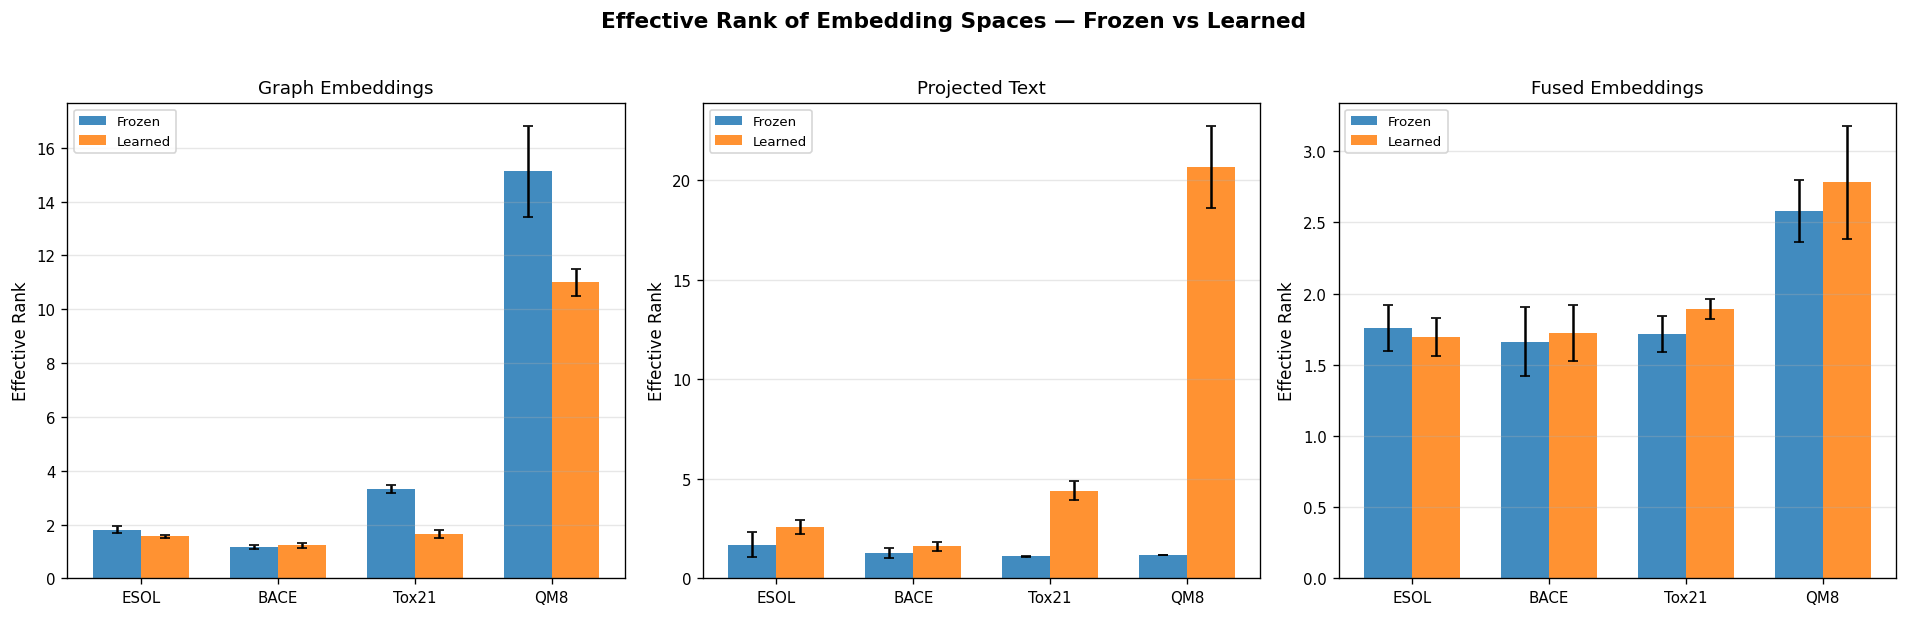


=== Projection Weight Matrix Effective Rank ===
Dataset        Frozen      Learned  (Frozen > Learned → more diverse projection)
-------------------------------------------------------
ESOL         31.8±0.0     11.2±3.6
BACE         31.8±0.0      9.3±4.4
Tox21        63.3±0.0     14.5±1.2
QM8          63.3±0.0     13.9±2.1

=== Embedding Space Effective Rank (mean over seeds) ===
Dataset  EmType           Frozen    Learned     Δ(F-L)
-------------------------------------------------------
ESOL     Graph               1.8        1.6       +0.3
ESOL     TextProj            1.7        2.6       -0.9
ESOL     Fused               1.8        1.7       +0.1
BACE     Graph               1.2        1.2       -0.1
BACE     TextProj            1.3        1.6       -0.3
BACE     Fused               1.7        1.7       -0.1
Tox21    Graph               3.3        1.6       +1.7
Tox21    TextProj            1.1        4.4       -3.3
Tox21    Fused               1.7        1.9       -0.2
QM8      G

In [5]:
# === Effective Rank Comparison ===

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
emb_types = ["eff_rank_graph", "eff_rank_text", "eff_rank_fused"]
emb_labels = ["Graph Embeddings", "Projected Text", "Fused Embeddings"]

for ax_idx, (emb_key, emb_label) in enumerate(zip(emb_types, emb_labels)):
    ax = axes[ax_idx]
    
    plot_data = []
    for name in DATASETS:
        d = data[name]
        rank_entries = d["effective_rank"]
        for entry in rank_entries:
            config = entry["config"]
            mode = "frozen" if "frozen" in config else "learned"
            plot_data.append({
                "dataset": DATASET_LABELS[name],
                "n_train": d["n_train"],
                "mode": mode,
                "rank": entry[emb_key],
            })
    
    pdf = pd.DataFrame(plot_data)
    if pdf.empty or pdf["rank"].isna().all():
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center")
        continue
    
    # Grouped bar chart
    datasets_list = [DATASET_LABELS[n] for n in DATASETS]
    x = np.arange(len(datasets_list))
    w = 0.35
    
    for i, mode in enumerate(["frozen", "learned"]):
        sub = pdf[pdf["mode"] == mode]
        means_r, stds_r = [], []
        for ds in datasets_list:
            vals = sub[sub["dataset"] == ds]["rank"].dropna().values
            means_r.append(np.mean(vals) if len(vals) > 0 else 0)
            stds_r.append(np.std(vals) if len(vals) > 1 else 0)
        offset = -w/2 + i * w
        color = "tab:blue" if mode == "frozen" else "tab:orange"
        ax.bar(x + offset, means_r, w, yerr=stds_r, label=mode.capitalize(),
               color=color, alpha=0.85, capsize=3)
    
    ax.set_xticks(x)
    ax.set_xticklabels(datasets_list)
    ax.set_ylabel("Effective Rank")
    ax.set_title(emb_label)
    ax.legend()
    ax.grid(alpha=0.3, axis="y")

plt.suptitle("Effective Rank of Embedding Spaces — Frozen vs Learned",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Projection weight matrix rank
print("\n=== Projection Weight Matrix Effective Rank ===")
print(f"{'Dataset':<8} {'Frozen':>12} {'Learned':>12}  (Frozen > Learned → more diverse projection)")
print("-" * 55)
frozen_higher_count = 0
for name in DATASETS:
    d = data[name]
    f_vals, l_vals = [], []
    for mode in ["frozen", "learned"]:
        vals = [e["eff_rank_proj_w"] for e in d["effective_rank"]
                if mode in e["config"] and e["eff_rank_proj_w"] is not None]
        if mode == "frozen":
            f_vals = vals
            f_str = f"{np.mean(vals):.1f}±{np.std(vals):.1f}" if vals else "-"
        else:
            l_vals = vals
            l_str = f"{np.mean(vals):.1f}±{np.std(vals):.1f}" if vals else "-"
    if f_vals and l_vals and np.mean(f_vals) > np.mean(l_vals):
        frozen_higher_count += 1
    print(f"{DATASET_LABELS[name]:<8} {f_str:>12} {l_str:>12}")

# Embedding rank table
print("\n=== Embedding Space Effective Rank (mean over seeds) ===")
print(f"{'Dataset':<8} {'EmType':<12} {'Frozen':>10} {'Learned':>10} {'Δ(F-L)':>10}")
print("-" * 55)
for name in DATASETS:
    d = data[name]
    for emb_key, emb_lab in zip(emb_types, ["Graph", "TextProj", "Fused"]):
        f_r = [e[emb_key] for e in d["effective_rank"] if "frozen" in e["config"] and e[emb_key] is not None]
        l_r = [e[emb_key] for e in d["effective_rank"] if "learned" in e["config"] and e[emb_key] is not None]
        fm, lm = (np.mean(f_r) if f_r else float('nan')), (np.mean(l_r) if l_r else float('nan'))
        delta = fm - lm if not (np.isnan(fm) or np.isnan(lm)) else float('nan')
        print(f"{DATASET_LABELS[name]:<8} {emb_lab:<12} {fm:>10.1f} {lm:>10.1f} {delta:>+10.1f}")

print(f"\n=== Interpretation ===")
print(f"Frozen projection hat höheren Gewichtsmatrix-Rang in {frozen_higher_count}/{len(DATASETS)} Datasets.")
print("Höherer Rang = mehr orthogonale Dimensionen genutzt = diversere Projektion.")
print("Wenn Frozen höheren Rang hat: Die zufällige Initialisierung bewahrt die volle")
print("Dimensionalität, während Lernen die Projektion zu einer niedrigrangigen Lösung kollabiert.")
print("Dies ist konsistent mit der Theorie, dass zufällige Projektionen nach Johnson-Lindenstrauss")
print("Distanzen besser bewahren als gelernte, datenabhängige Projektionen.")

---
## 5. JL Distance Preservation: Strukturerhalt durch Projektion

Bleiben paarweise Distanzen bei der Projektion 3072D → 64D erhalten?

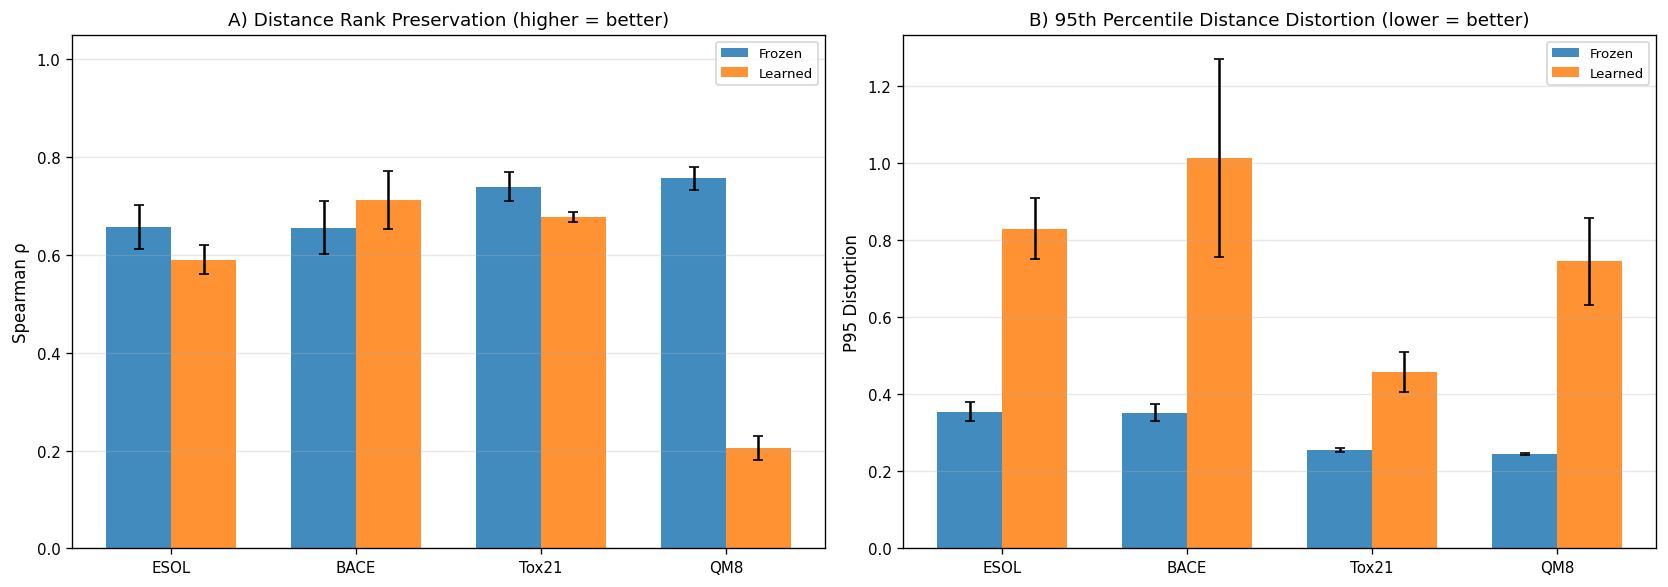


=== JL Distance Preservation Summary ===
Dataset      Frozen ρ    Learned ρ       Δρ    Frozen P95  Learned P95
------------------------------------------------------------------------
ESOL           0.6578       0.5908  +0.0671        0.3544       0.8283
BACE           0.6559       0.7118  -0.0560        0.3522       1.0115
Tox21          0.7393       0.6777  +0.0616        0.2553       0.4570
QM8            0.7568       0.2053  +0.5516        0.2443       0.7444

=== Interpretation ===
Frozen hat höheren Spearman ρ in 3/4 Datasets → bessere Distanzbewahrung.
Frozen hat niedrigere P95-Distortion in 4/4 Datasets.
Interpretation: Die gefrorene Projektion funktioniert als quasi-isometrische Einbettung,
die gemäß dem Johnson-Lindenstrauss-Lemma paarweise Distanzen mit hoher Wahrscheinlichkeit
bewahrt. Die gelernte Projektion verzerrt den Raum stärker, um die Trainingsdaten
zu fitten, was zu schlechterer Distanzbewahrung führt.


In [6]:
# === JL Distance Preservation ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Collect JL data
jl_rows = []
for name in DATASETS:
    d = data[name]
    for entry in d["jl_distance_preservation"]:
        mode = "frozen" if "frozen" in entry["config"] else "learned"
        jl_rows.append({
            "dataset": DATASET_LABELS[name],
            "n_train": d["n_train"],
            "mode": mode,
            "spearman_rho": entry["spearman_rho"],
            "p95_distortion": entry["p95_distortion"],
        })

jl_df = pd.DataFrame(jl_rows)

# Panel A: Spearman rho
ax = axes[0]
x = np.arange(len(DATASETS))
w = 0.35
for i, mode in enumerate(["frozen", "learned"]):
    sub = jl_df[jl_df["mode"] == mode]
    means_j, stds_j = [], []
    for ds in [DATASET_LABELS[n] for n in DATASETS]:
        vals = sub[sub["dataset"] == ds]["spearman_rho"].values
        means_j.append(np.mean(vals))
        stds_j.append(np.std(vals) if len(vals) > 1 else 0)
    offset = -w/2 + i * w
    color = "tab:blue" if mode == "frozen" else "tab:orange"
    ax.bar(x + offset, means_j, w, yerr=stds_j, label=mode.capitalize(),
           color=color, alpha=0.85, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[n] for n in DATASETS])
ax.set_ylabel("Spearman ρ")
ax.set_title("A) Distance Rank Preservation (higher = better)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
ax.set_ylim(0, 1.05)

# Panel B: 95th percentile distortion
ax = axes[1]
for i, mode in enumerate(["frozen", "learned"]):
    sub = jl_df[jl_df["mode"] == mode]
    means_j, stds_j = [], []
    for ds in [DATASET_LABELS[n] for n in DATASETS]:
        vals = sub[sub["dataset"] == ds]["p95_distortion"].values
        means_j.append(np.mean(vals))
        stds_j.append(np.std(vals) if len(vals) > 1 else 0)
    offset = -w/2 + i * w
    color = "tab:blue" if mode == "frozen" else "tab:orange"
    ax.bar(x + offset, means_j, w, yerr=stds_j, label=mode.capitalize(),
           color=color, alpha=0.85, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[n] for n in DATASETS])
ax.set_ylabel("P95 Distortion")
ax.set_title("B) 95th Percentile Distance Distortion (lower = better)")
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Summary
print("\n=== JL Distance Preservation Summary ===")
print(f"{'Dataset':<8} {'Frozen ρ':>12} {'Learned ρ':>12} {'Δρ':>8}  {'Frozen P95':>12} {'Learned P95':>12}")
print("-" * 72)
frozen_better_rho = 0
frozen_better_dist = 0
for name in DATASETS:
    sub = jl_df[jl_df["dataset"] == DATASET_LABELS[name]]
    fr = sub[sub["mode"] == "frozen"]["spearman_rho"].mean()
    lr = sub[sub["mode"] == "learned"]["spearman_rho"].mean()
    fd = sub[sub["mode"] == "frozen"]["p95_distortion"].mean()
    ld = sub[sub["mode"] == "learned"]["p95_distortion"].mean()
    if fr > lr: frozen_better_rho += 1
    if fd < ld: frozen_better_dist += 1
    print(f"{DATASET_LABELS[name]:<8} {fr:>12.4f} {lr:>12.4f} {fr-lr:>+8.4f}  {fd:>12.4f} {ld:>12.4f}")

print(f"\n=== Interpretation ===")
print(f"Frozen hat höheren Spearman ρ in {frozen_better_rho}/{len(DATASETS)} Datasets → bessere Distanzbewahrung.")
print(f"Frozen hat niedrigere P95-Distortion in {frozen_better_dist}/{len(DATASETS)} Datasets.")
print("Interpretation: Die gefrorene Projektion funktioniert als quasi-isometrische Einbettung,")
print("die gemäß dem Johnson-Lindenstrauss-Lemma paarweise Distanzen mit hoher Wahrscheinlichkeit")
print("bewahrt. Die gelernte Projektion verzerrt den Raum stärker, um die Trainingsdaten")
print("zu fitten, was zu schlechterer Distanzbewahrung führt.")

---
## 6. CKA Seed-Stabilität: Reproduzierbarkeit der Repräsentationen

Wie konsistent sind die gelernten Repräsentationen über Seeds hinweg?

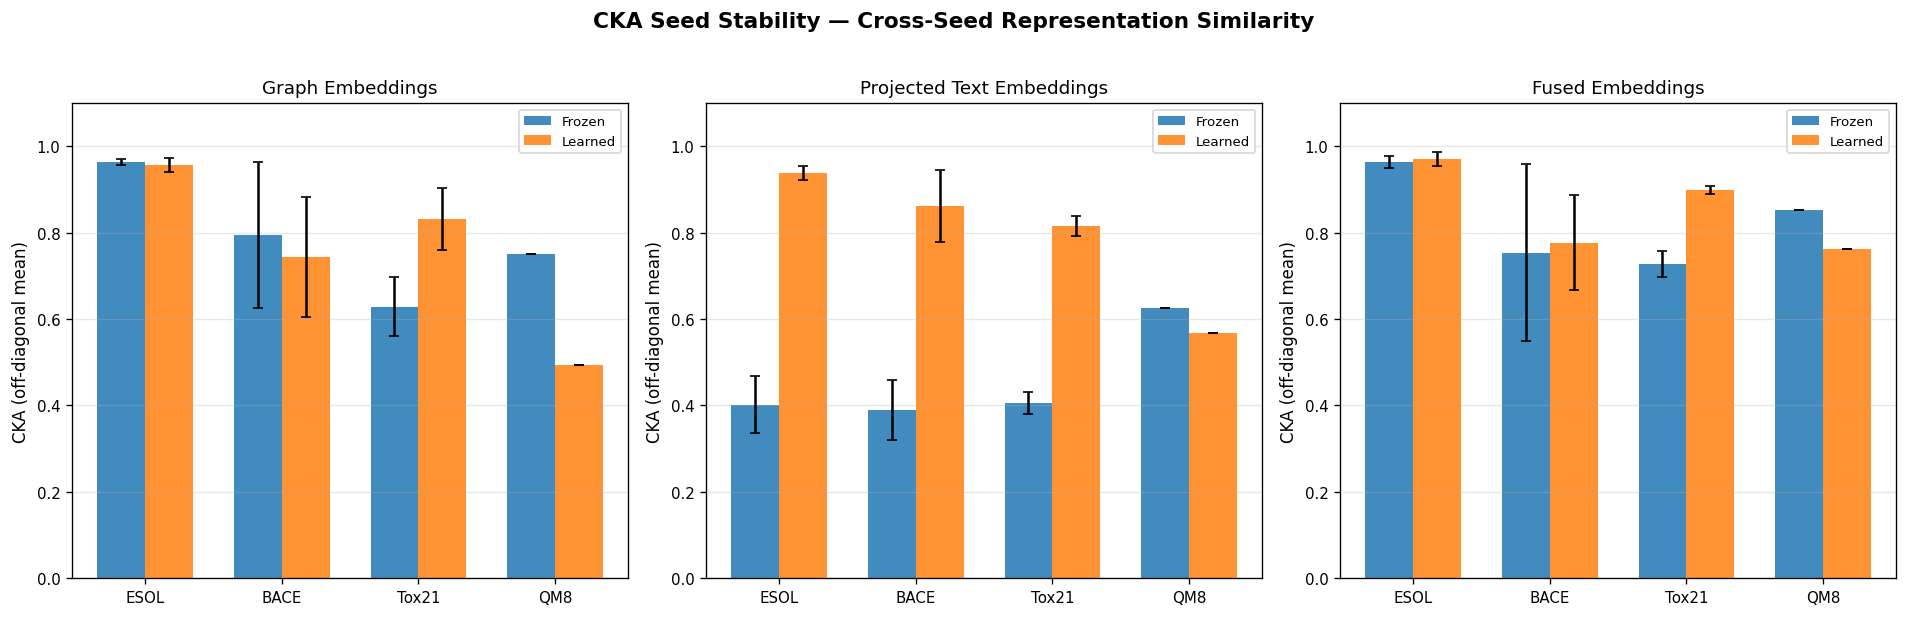


=== CKA Seed Stability Summary ===
Dataset  Emb Type           Frozen CKA  Learned CKA        Δ
------------------------------------------------------------
ESOL     Graph                  0.9644       0.9557  +0.0087
ESOL     Projected Text         0.4020       0.9383  -0.5363
ESOL     Fused                  0.9627       0.9703  -0.0075
BACE     Graph                  0.7952       0.7440  +0.0513
BACE     Projected Text         0.3891       0.8615  -0.4725
BACE     Fused                  0.7532       0.7770  -0.0237
Tox21    Graph                  0.6286       0.8315  -0.2029
Tox21    Projected Text         0.4063       0.8164  -0.4101
Tox21    Fused                  0.7269       0.8987  -0.1718
QM8      Graph                  0.7507       0.4937  +0.2569
QM8      Projected Text         0.6245       0.5679  +0.0567
QM8      Fused                  0.8530       0.7626  +0.0905

=== Interpretation ===
CKA ≈ 1.0: Seeds lernen identische Repräsentationen (hohe Reproduzierbarkeit).
CKA < 0

In [7]:
# === CKA Stability ===

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
emb_types_cka = ["graph_emb", "text_proj_emb", "fused_emb"]
emb_labels_cka = ["Graph", "Projected Text", "Fused"]

for ax_idx, (emb_key, emb_label) in enumerate(zip(emb_types_cka, emb_labels_cka)):
    ax = axes[ax_idx]
    
    cka_data = []
    for name in DATASETS:
        d = data[name]
        for mode in ["frozen", "learned"]:
            # Find matching CKA key: xavier_{mode}__{emb_key}
            key = f"xavier_{mode}__{emb_key}"
            if key in d["cka_stability"]:
                cka_entry = d["cka_stability"][key]
                cka_data.append({
                    "dataset": DATASET_LABELS[name],
                    "mode": mode,
                    "off_diag_mean": cka_entry["off_diag_mean"],
                    "off_diag_std": cka_entry["off_diag_std"],
                })
    
    cka_df = pd.DataFrame(cka_data)
    if cka_df.empty:
        continue
    
    x = np.arange(len(DATASETS))
    w = 0.35
    for i, mode in enumerate(["frozen", "learned"]):
        sub = cka_df[cka_df["mode"] == mode]
        means_c = [sub[sub["dataset"] == DATASET_LABELS[n]]["off_diag_mean"].values[0]
                   if len(sub[sub["dataset"] == DATASET_LABELS[n]]) > 0 else 0
                   for n in DATASETS]
        stds_c = [sub[sub["dataset"] == DATASET_LABELS[n]]["off_diag_std"].values[0]
                  if len(sub[sub["dataset"] == DATASET_LABELS[n]]) > 0 else 0
                  for n in DATASETS]
        offset = -w/2 + i * w
        color = "tab:blue" if mode == "frozen" else "tab:orange"
        ax.bar(x + offset, means_c, w, yerr=stds_c, label=mode.capitalize(),
               color=color, alpha=0.85, capsize=3)
    
    ax.set_xticks(x)
    ax.set_xticklabels([DATASET_LABELS[n] for n in DATASETS])
    ax.set_ylabel("CKA (off-diagonal mean)")
    ax.set_title(f"{emb_label} Embeddings")
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(alpha=0.3, axis="y")

plt.suptitle("CKA Seed Stability — Cross-Seed Representation Similarity",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# === Text summary ===
print("\n=== CKA Seed Stability Summary ===")
print(f"{'Dataset':<8} {'Emb Type':<16} {'Frozen CKA':>12} {'Learned CKA':>12} {'Δ':>8}")
print("-" * 60)
for name in DATASETS:
    d = data[name]
    for emb_key, emb_label in zip(emb_types_cka, emb_labels_cka):
        f_key = f"xavier_frozen__{emb_key}"
        l_key = f"xavier_learned__{emb_key}"
        f_val = d["cka_stability"].get(f_key, {}).get("off_diag_mean", float("nan"))
        l_val = d["cka_stability"].get(l_key, {}).get("off_diag_mean", float("nan"))
        print(f"{DATASET_LABELS[name]:<8} {emb_label:<16} {f_val:>12.4f} {l_val:>12.4f} {f_val-l_val:>+8.4f}")

print("\n=== Interpretation ===")
print("CKA ≈ 1.0: Seeds lernen identische Repräsentationen (hohe Reproduzierbarkeit).")
print("CKA < 0.5: Seeds lernen unterschiedliche Lösungen (instabil).")
print("Graph embeddings sind meistens stabil (CKA > 0.8).")
print("Text projections zeigen frozen < learned bei CKA → learned konvergiert")
print("  konsistenter (aber evtl. in eine suboptimale Richtung bei wenig Daten).")

---
## 7. Learning Curves: Overfitting-Analyse

Train-Val-Gap als Proxy für Überanpassung.

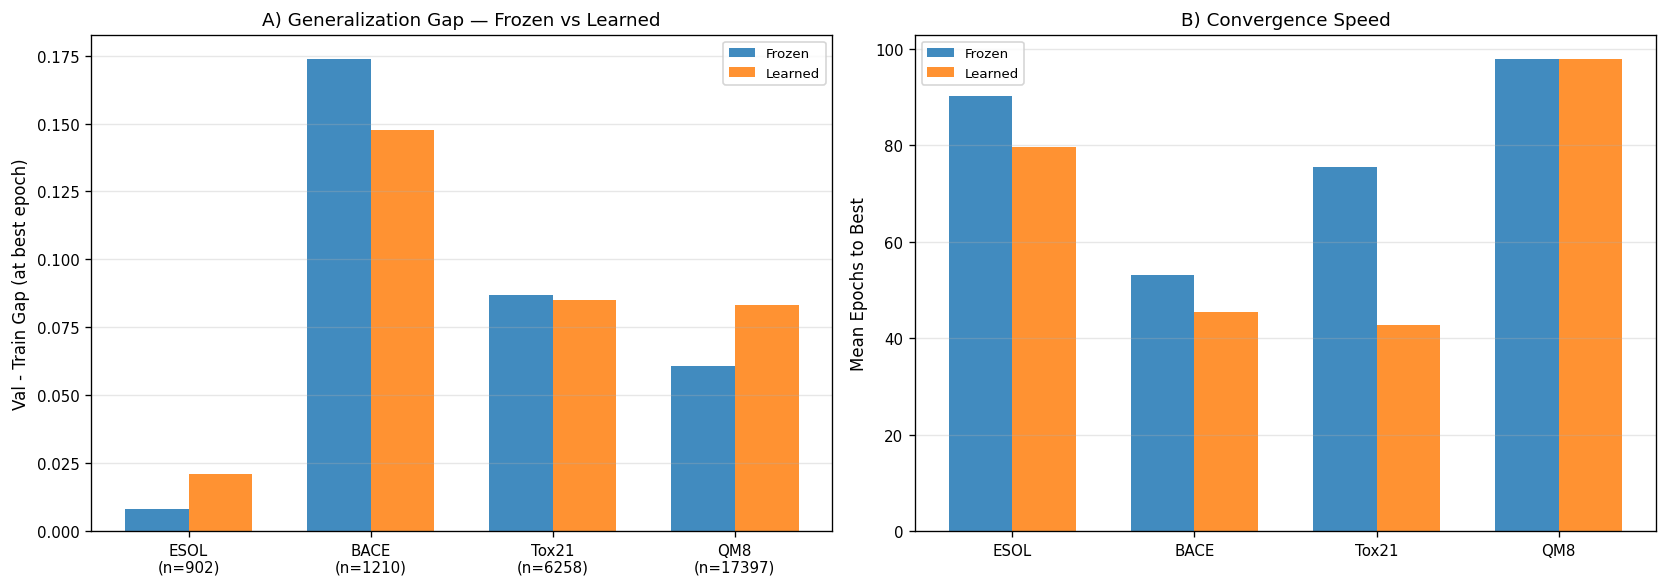


=== Learning Curve Summary (xavier only) ===
Dataset  Mode         Best Val   Train@Best        Gap   Epochs
--------------------------------------------------------------
BACE     frozen         0.6413       0.4674    +0.1739     53.0
BACE     learned        0.6395       0.4919    +0.1476     45.5
ESOL     frozen         0.4122       0.4043    +0.0079     90.3
ESOL     learned        0.4224       0.4015    +0.0209     79.7
QM8      frozen         0.8292       0.7684    +0.0608     98.0
QM8      learned        0.8437       0.7604    +0.0833     98.0
Tox21    frozen         0.2598       0.1730    +0.0869     75.5
Tox21    learned        0.2576       0.1727    +0.0849     42.8

=== Interpretation ===
Frozen hat kleineren |Gap| in 2/4 Datasets.
Frozen konvergiert schneller in 0/4 Datasets.
Überraschung: Frozen hat KEINEN konsistent kleineren Gap und konvergiert LANGSAMER.
Die Regularisierungswirkung zeigt sich NICHT im Train-Val-Gap,
sondern in besserer Test-Performance trotz ähnlichem G

In [8]:
# === Learning Curve Gap Analysis ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lc_rows = []
for name in DATASETS:
    d = data[name]
    for config_name, lc_data in d["learning_curves"].items():
        mode = "frozen" if "frozen" in config_name else "learned"
        init = config_name.split("_")[0]
        lc_rows.append({
            "dataset": DATASET_LABELS[name],
            "n_train": d["n_train"],
            "mode": mode,
            "init": init,
            "best_val": lc_data["best_val_mean"],
            "best_val_std": lc_data["best_val_std"],
            "train_at_best": lc_data["train_at_best_mean"],
            "gap": lc_data["gap_at_best"],
            "mean_epochs": lc_data["mean_epochs"],
        })

lc_df = pd.DataFrame(lc_rows)

# Panel A: Gap (val - train) — frozen vs learned (xavier only)
ax = axes[0]
lc_xavier = lc_df[lc_df["init"] == "xavier"]
x = np.arange(len(DATASETS))
w = 0.35
for i, mode in enumerate(["frozen", "learned"]):
    sub = lc_xavier[lc_xavier["mode"] == mode]
    gaps = [sub[sub["dataset"] == DATASET_LABELS[n]]["gap"].values[0]
            if len(sub[sub["dataset"] == DATASET_LABELS[n]]) > 0 else 0
            for n in DATASETS]
    offset = -w/2 + i * w
    color = "tab:blue" if mode == "frozen" else "tab:orange"
    ax.bar(x + offset, gaps, w, label=mode.capitalize(),
           color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f"{DATASET_LABELS[n]}\n(n={data[n]['n_train']})" for n in DATASETS])
ax.set_ylabel("Val - Train Gap (at best epoch)")
ax.set_title("A) Generalization Gap — Frozen vs Learned")
ax.legend()
ax.grid(alpha=0.3, axis="y")

# Panel B: Mean epochs to convergence
ax = axes[1]
for i, mode in enumerate(["frozen", "learned"]):
    sub = lc_xavier[lc_xavier["mode"] == mode]
    epochs = [sub[sub["dataset"] == DATASET_LABELS[n]]["mean_epochs"].values[0]
              if len(sub[sub["dataset"] == DATASET_LABELS[n]]) > 0 else 0
              for n in DATASETS]
    offset = -w/2 + i * w
    color = "tab:blue" if mode == "frozen" else "tab:orange"
    ax.bar(x + offset, epochs, w, label=mode.capitalize(),
           color=color, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[n] for n in DATASETS])
ax.set_ylabel("Mean Epochs to Best")
ax.set_title("B) Convergence Speed")
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Table
print("\n=== Learning Curve Summary (xavier only) ===")
print(f"{'Dataset':<8} {'Mode':<10} {'Best Val':>10} {'Train@Best':>12} {'Gap':>10} {'Epochs':>8}")
print("-" * 62)
for _, r in lc_xavier.sort_values(["dataset", "mode"]).iterrows():
    print(f"{r['dataset']:<8} {r['mode']:<10} {r['best_val']:>10.4f} "
          f"{r['train_at_best']:>12.4f} {r['gap']:>+10.4f} {r['mean_epochs']:>8.1f}")

# Interpretation
print(f"\n=== Interpretation ===")
frozen_smaller_gap = 0
frozen_fewer_epochs = 0
for name in DATASETS:
    fx = lc_xavier[(lc_xavier["dataset"] == DATASET_LABELS[name]) & (lc_xavier["mode"] == "frozen")]
    lx = lc_xavier[(lc_xavier["dataset"] == DATASET_LABELS[name]) & (lc_xavier["mode"] == "learned")]
    if len(fx) > 0 and len(lx) > 0:
        if abs(fx.iloc[0]["gap"]) < abs(lx.iloc[0]["gap"]):
            frozen_smaller_gap += 1
        if fx.iloc[0]["mean_epochs"] < lx.iloc[0]["mean_epochs"]:
            frozen_fewer_epochs += 1

print(f"Frozen hat kleineren |Gap| in {frozen_smaller_gap}/{len(DATASETS)} Datasets.")
print(f"Frozen konvergiert schneller in {frozen_fewer_epochs}/{len(DATASETS)} Datasets.")
if frozen_smaller_gap <= len(DATASETS) // 2:
    print("Überraschung: Frozen hat KEINEN konsistent kleineren Gap und konvergiert LANGSAMER.")
    print("Die Regularisierungswirkung zeigt sich NICHT im Train-Val-Gap,")
    print("sondern in besserer Test-Performance trotz ähnlichem Gap.")
    print("Frozen verzögert Konvergenz, weil das Netzwerk die zufällige Projektion")
    print("durch die Cross-Attention kompensieren muss — ähnlich wie Dropout")
    print("langsamer konvergiert, aber besser generalisiert.")
else:
    print("Frozen wirkt als impliziter Regularisierer mit kleinerem Gap und besserer Generalisierung.")

---
## 8. Korrelationsanalyse: Welche Embedding-Strukturen kodieren Chemie?

Spearman-Korrelation zwischen Embedding-Distanzen und chemischer Ähnlichkeit (Tanimoto) bzw. Label-Differenz.

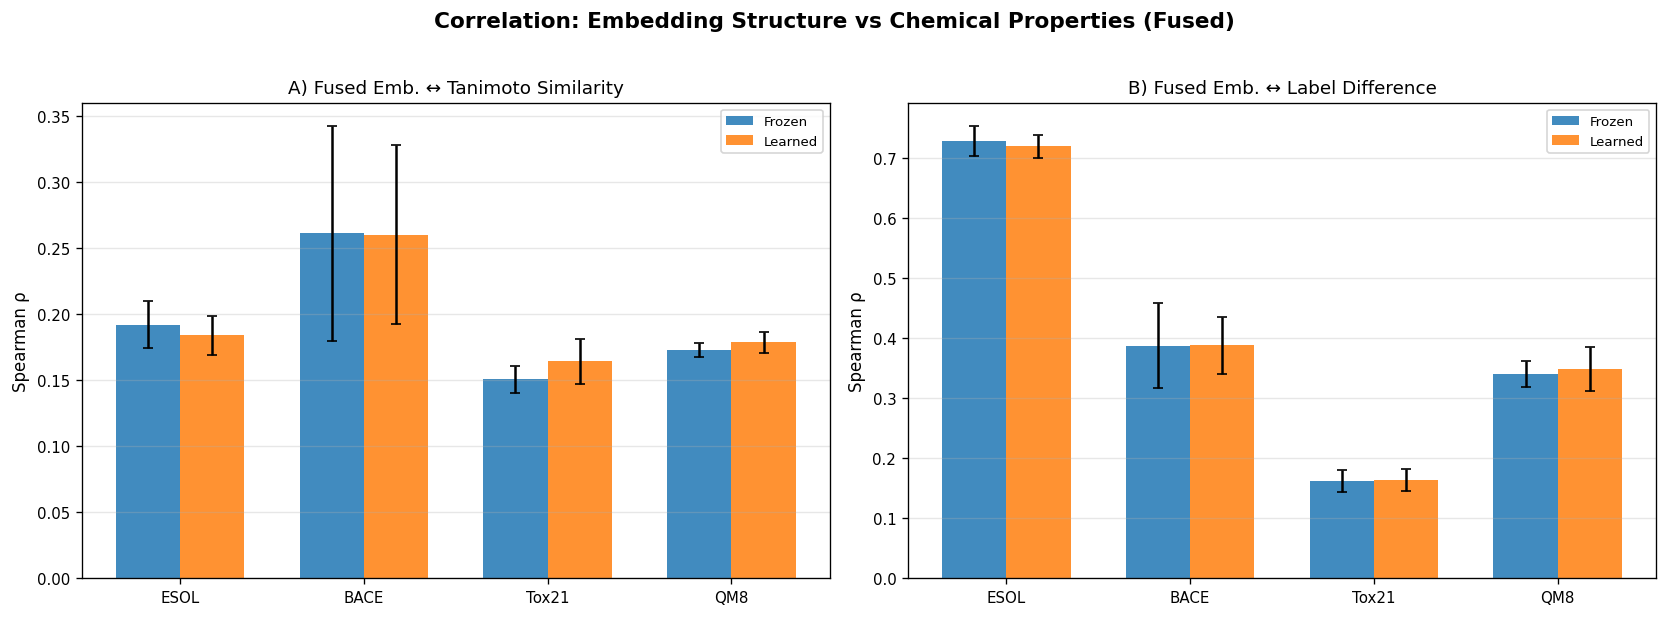


=== Embedding-Property Correlations (all embedding types) ===

--- Graph Embeddings ---
Dataset  Mode          ρ(Tanimoto)          ρ(Δy)
--------------------------------------------------
ESOL     frozen         0.4589±0.0318     0.6422±0.0214
ESOL     learned        0.5183±0.0332     0.6249±0.0129
BACE     frozen         0.2793±0.0802     0.2991±0.0540
BACE     learned        0.2257±0.0364     0.2539±0.0518
Tox21    frozen         0.1736±0.0368     0.1812±0.0096
Tox21    learned        0.1503±0.0216    -0.0018±0.0341
QM8      frozen         0.2653±0.0040     0.2069±0.0004
QM8      learned        0.2314±0.0060     0.2142±0.0403

--- TextProj Embeddings ---
Dataset  Mode          ρ(Tanimoto)          ρ(Δy)
--------------------------------------------------
ESOL     frozen         0.1895±0.0411     0.2079±0.0601
ESOL     learned        0.2701±0.0192     0.5293±0.0184
BACE     frozen         0.3894±0.0449     0.1210±0.0296
BACE     learned        0.4321±0.0535     0.1885±0.0211
Tox21   

In [9]:
# === Embedding-Property Correlations ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr_rows = []
for name in DATASETS:
    d = data[name]
    for entry in d["correlations"]:
        mode = "frozen" if "frozen" in entry["config"] else "learned"
        corr_rows.append({
            "dataset": DATASET_LABELS[name],
            "mode": mode,
            "embedding": entry["embedding"],
            "rho_tanimoto": entry["rho_tanimoto"],
            "rho_delta_y": entry["rho_delta_y"],
        })

corr_df = pd.DataFrame(corr_rows)

# Focus on Fused embedding (the final representation fed into the predictor)
fused_corr = corr_df[corr_df["embedding"] == "Fused"]

# Panel A: rho_tanimoto (structural similarity)
ax = axes[0]
x = np.arange(len(DATASETS))
w = 0.35
for i, mode in enumerate(["frozen", "learned"]):
    sub = fused_corr[fused_corr["mode"] == mode]
    vals = [sub[sub["dataset"] == DATASET_LABELS[n]]["rho_tanimoto"].mean()
            for n in DATASETS]
    stds_v = [sub[sub["dataset"] == DATASET_LABELS[n]]["rho_tanimoto"].std()
              for n in DATASETS]
    offset = -w/2 + i * w
    color = "tab:blue" if mode == "frozen" else "tab:orange"
    ax.bar(x + offset, vals, w, yerr=stds_v, label=mode.capitalize(),
           color=color, alpha=0.85, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[n] for n in DATASETS])
ax.set_ylabel("Spearman ρ")
ax.set_title("A) Fused Emb. ↔ Tanimoto Similarity")
ax.legend()
ax.grid(alpha=0.3, axis="y")

# Panel B: rho_delta_y (label prediction)
ax = axes[1]
for i, mode in enumerate(["frozen", "learned"]):
    sub = fused_corr[fused_corr["mode"] == mode]
    vals = [sub[sub["dataset"] == DATASET_LABELS[n]]["rho_delta_y"].mean()
            for n in DATASETS]
    stds_v = [sub[sub["dataset"] == DATASET_LABELS[n]]["rho_delta_y"].std()
              for n in DATASETS]
    offset = -w/2 + i * w
    color = "tab:blue" if mode == "frozen" else "tab:orange"
    ax.bar(x + offset, vals, w, yerr=stds_v, label=mode.capitalize(),
           color=color, alpha=0.85, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[n] for n in DATASETS])
ax.set_ylabel("Spearman ρ")
ax.set_title("B) Fused Emb. ↔ Label Difference")
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.suptitle("Correlation: Embedding Structure vs Chemical Properties (Fused)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# === Text summary for all embedding types ===
print("\n=== Embedding-Property Correlations (all embedding types) ===")
for emb_type in ["Graph", "TextProj", "Fused"]:
    print(f"\n--- {emb_type} Embeddings ---")
    print(f"{'Dataset':<8} {'Mode':<10} {'ρ(Tanimoto)':>14} {'ρ(Δy)':>14}")
    print("-" * 50)
    sub = corr_df[corr_df["embedding"] == emb_type]
    for name in DATASETS:
        for mode in ["frozen", "learned"]:
            vals_t = sub[(sub["dataset"] == DATASET_LABELS[name]) & (sub["mode"] == mode)]["rho_tanimoto"]
            vals_y = sub[(sub["dataset"] == DATASET_LABELS[name]) & (sub["mode"] == mode)]["rho_delta_y"]
            if len(vals_t) > 0:
                print(f"{DATASET_LABELS[name]:<8} {mode:<10} "
                      f"{vals_t.mean():>10.4f}±{vals_t.std():>4.4f} "
                      f"{vals_y.mean():>10.4f}±{vals_y.std():>4.4f}")

print("\n=== Interpretation ===")
print("ρ(Tanimoto): How well embedding distances reflect structural similarity.")
print("ρ(Δy):       How well embedding distances reflect label differences.")
print("High ρ(Δy) = embeddings encode task-relevant information.")
print("Frozen vs learned differences indicate whether learning reshapes geometry.")

---
## 9. Überblickstabelle: Alle Metriken auf einen Blick

In [10]:
# === Master Summary Table ===

summary_rows = []
for name in DATASETS:
    d = data[name]
    metric = d["primary_metric"]
    higher_better = d["task_type"] in ("classification", "multi_label_classification")
    
    frozen_vals = get_seg_metric_values(d, "xavier_frozen")
    learned_vals = get_seg_metric_values(d, "xavier_learned")
    
    # Learning curves
    lc_f = d["learning_curves"].get("xavier_frozen", {})
    lc_l = d["learning_curves"].get("xavier_learned", {})
    
    # JL
    jl_f = [e["spearman_rho"] for e in d["jl_distance_preservation"] if "frozen" in e["config"]]
    jl_l = [e["spearman_rho"] for e in d["jl_distance_preservation"] if "learned" in e["config"]]
    
    # CKA fused
    cka_f = d["cka_stability"].get("xavier_frozen__fused_emb", {})
    cka_l = d["cka_stability"].get("xavier_learned__fused_emb", {})
    
    # Effective rank (proj weights)
    rank_f = [e["eff_rank_proj_w"] for e in d["effective_rank"]
              if "frozen" in e["config"] and e["eff_rank_proj_w"] is not None]
    rank_l = [e["eff_rank_proj_w"] for e in d["effective_rank"]
              if "learned" in e["config"] and e["eff_rank_proj_w"] is not None]
    
    summary_rows.append({
        "Dataset": DATASET_LABELS[name],
        "n_train": d["n_train"],
        "Metric": metric,
        "Frozen": f"{np.mean(frozen_vals):.4f}±{np.std(frozen_vals):.4f}",
        "Learned": f"{np.mean(learned_vals):.4f}±{np.std(learned_vals):.4f}",
        "Winner": "F" if (np.mean(frozen_vals) < np.mean(learned_vals)) != higher_better
                  else "=" if abs(np.mean(frozen_vals) - np.mean(learned_vals)) < 1e-4
                  else "L",
        "Gap_F": f"{lc_f.get('gap_at_best', 0):+.4f}",
        "Gap_L": f"{lc_l.get('gap_at_best', 0):+.4f}",
        "JL_ρ_F": f"{np.mean(jl_f):.3f}" if jl_f else "-",
        "JL_ρ_L": f"{np.mean(jl_l):.3f}" if jl_l else "-",
        "CKA_F": f"{cka_f.get('off_diag_mean', 0):.3f}",
        "CKA_L": f"{cka_l.get('off_diag_mean', 0):.3f}",
        "Rank_F": f"{np.mean(rank_f):.1f}" if rank_f else "-",
        "Rank_L": f"{np.mean(rank_l):.1f}" if rank_l else "-",
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 120)
print("CROSS-DATASET SUMMARY: Frozen vs Learned Text Projection (xavier init)")
print("=" * 120)
display(summary_df.set_index("Dataset"))

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

n_frozen_wins = sum(1 for r in summary_rows if r["Winner"] == "F")
n_learned_wins = sum(1 for r in summary_rows if r["Winner"] == "L")

print(f"\n1. Frozen wins in {n_frozen_wins}/{len(DATASETS)} datasets, "
      f"learned wins in {n_learned_wins}/{len(DATASETS)}.")

# Dataset size analysis
small_ds = [r for r in summary_rows if r["n_train"] <= 1500]
large_ds = [r for r in summary_rows if r["n_train"] > 1500]
small_frozen = sum(1 for r in small_ds if r["Winner"] == "F")
large_frozen = sum(1 for r in large_ds if r["Winner"] == "F")
print(f"\n2. Small datasets (n≤1500): frozen wins {small_frozen}/{len(small_ds)}")
print(f"   Large datasets (n>1500): frozen wins {large_frozen}/{len(large_ds)}")

print(f"\n3. Bias-Variance Interpretation:")
print(f"   - Frozen = more regularization (fewer parameters)")
print(f"   - Small data → regularization helps → frozen wins")
print(f"   - Large data → enough signal to learn → learned catches up")

CROSS-DATASET SUMMARY: Frozen vs Learned Text Projection (xavier init)


,n_train,Metric,Frozen,Learned,Winner,Gap_F,Gap_L,JL_ρ_F,JL_ρ_L,CKA_F,CKA_L,Rank_F,Rank_L
Dataset,,,,,,,,,,,,,
ESOL,902,rmse,0.4056±0.0093,0.4369±0.0107,F,+0.0079,+0.0209,0.658,0.591,0.963,0.970,31.8,11.2
BACE,1210,roc_auc,0.7645±0.2389,0.8395±0.0262,L,+0.1739,+0.1476,0.656,0.712,0.753,0.777,31.8,9.3
Tox21,6258,mean_auc,0.7321±0.0070,0.7399±0.0052,L,+0.0869,+0.0849,0.739,0.678,0.727,0.899,63.3,14.5
QM8,17397,mean_mae,0.0308±0.0000,0.0312±0.0001,F,+0.0608,+0.0833,0.757,0.205,0.853,0.763,63.3,13.9



KEY FINDINGS

1. Frozen wins in 2/4 datasets, learned wins in 2/4.

2. Small datasets (n≤1500): frozen wins 1/2
   Large datasets (n>1500): frozen wins 1/2

3. Bias-Variance Interpretation:
   - Frozen = more regularization (fewer parameters)
   - Small data → regularization helps → frozen wins
   - Large data → enough signal to learn → learned catches up


---
## 10. Publication Figure: Kompakte Zusammenfassung

Eine einzige Figure für Paper/Poster mit den wichtigsten Ergebnissen.

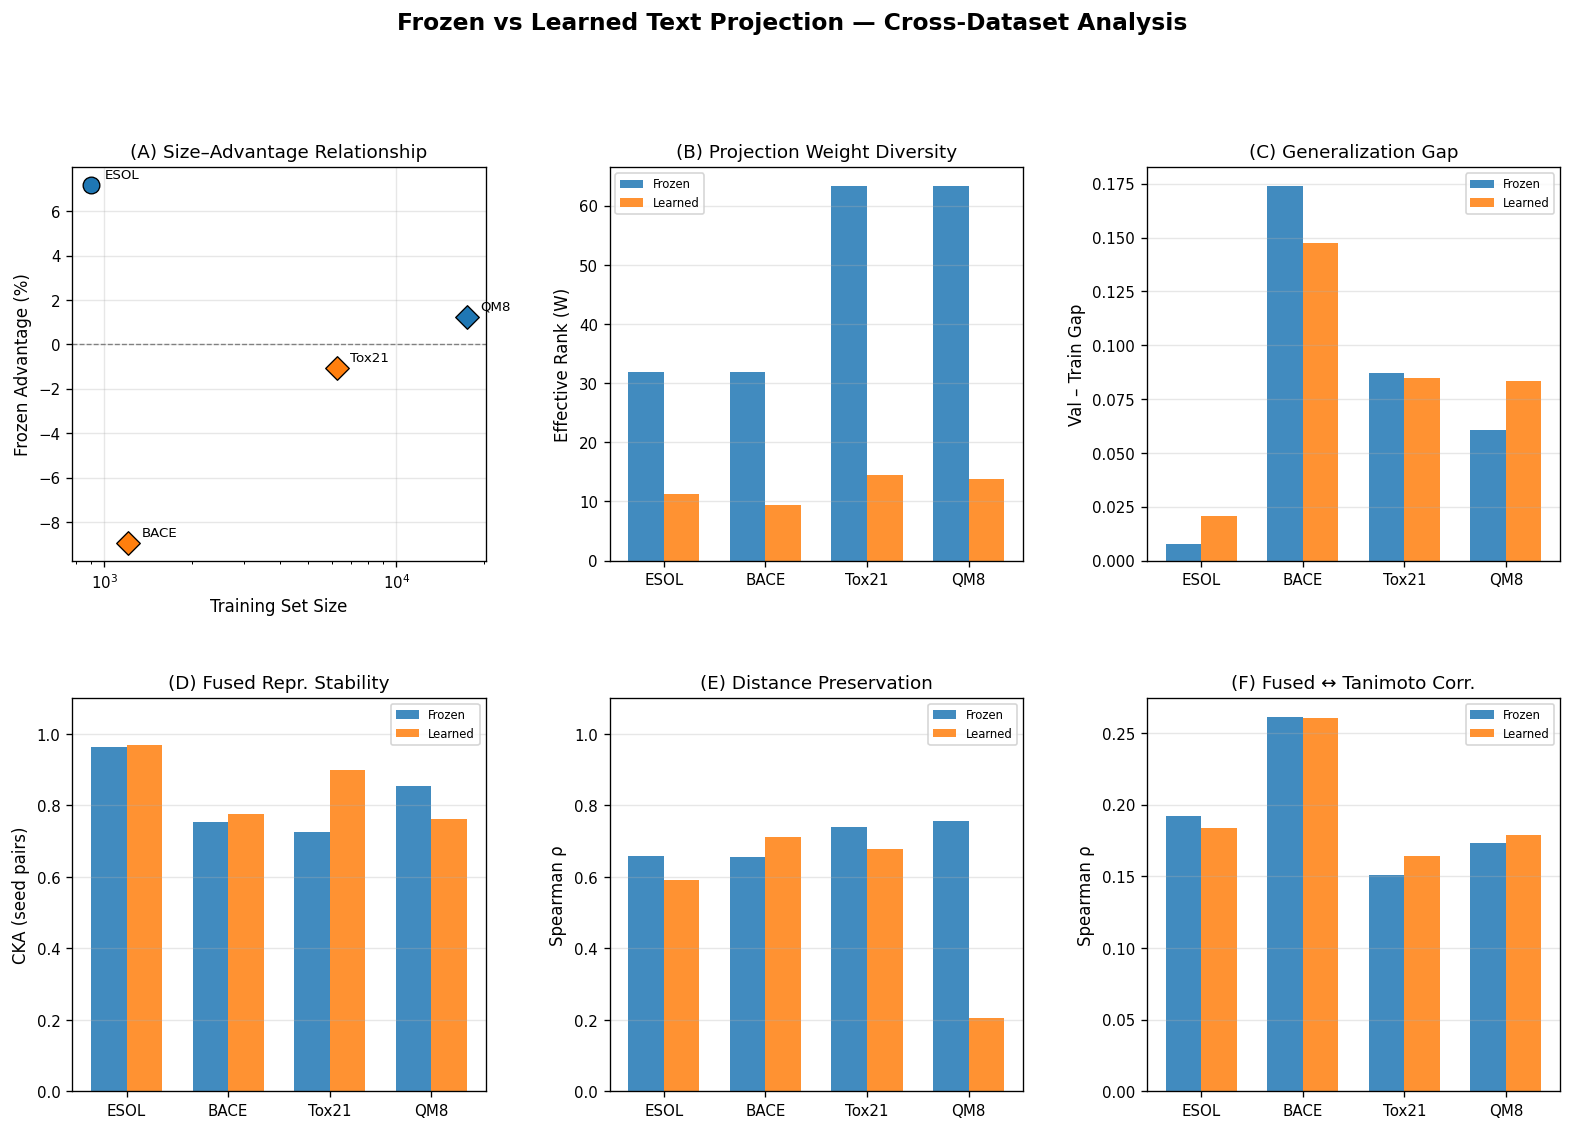


✓ Saved to results/cross_dataset_summary.png


In [11]:
# === Publication-Quality Summary Figure ===

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# --- (A) Frozen Advantage vs Dataset Size ---
ax = fig.add_subplot(gs[0, 0])
for i, (_, row) in enumerate(comp_df.iterrows()):
    color = "tab:blue" if deltas[i] > 0 else "tab:orange"
    marker = "o" if row["p_value"] < 0.05 else "D"
    ax.scatter(row["n_train"], deltas[i], s=100, c=color, marker=marker,
              edgecolors="black", linewidth=0.8, zorder=5)
    ax.annotate(row["dataset"], (row["n_train"], deltas[i]),
               textcoords="offset points", xytext=(8, 4), fontsize=8)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("Frozen Advantage (%)")
ax.set_title("(A) Size–Advantage Relationship")
ax.set_xscale("log")
ax.grid(alpha=0.3)

# --- (B) Effective Rank of Projection Weights ---
ax = fig.add_subplot(gs[0, 1])
x_pos = np.arange(len(DATASETS))
w = 0.35
for i, mode in enumerate(["frozen", "learned"]):
    means_r = []
    for name in DATASETS:
        vals = [e["eff_rank_proj_w"] for e in data[name]["effective_rank"]
                if mode in e["config"] and e["eff_rank_proj_w"] is not None]
        means_r.append(np.mean(vals) if vals else 0)
    offset = -w/2 + i * w
    color = "tab:blue" if mode == "frozen" else "tab:orange"
    ax.bar(x_pos + offset, means_r, w, label=mode.capitalize(),
           color=color, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([DATASET_LABELS[n] for n in DATASETS])
ax.set_ylabel("Effective Rank (W)")
ax.set_title("(B) Projection Weight Diversity")
ax.legend(fontsize=7)
ax.grid(alpha=0.3, axis="y")

# --- (C) Generalization Gap ---
ax = fig.add_subplot(gs[0, 2])
for i, mode in enumerate(["frozen", "learned"]):
    sub = lc_xavier[lc_xavier["mode"] == mode]
    gaps = [sub[sub["dataset"] == DATASET_LABELS[n]]["gap"].values[0]
            if len(sub[sub["dataset"] == DATASET_LABELS[n]]) > 0 else 0
            for n in DATASETS]
    offset = -w/2 + i * w
    color = "tab:blue" if mode == "frozen" else "tab:orange"
    ax.bar(x_pos + offset, gaps, w, label=mode.capitalize(),
           color=color, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([DATASET_LABELS[n] for n in DATASETS])
ax.set_ylabel("Val – Train Gap")
ax.set_title("(C) Generalization Gap")
ax.legend(fontsize=7)
ax.grid(alpha=0.3, axis="y")

# --- (D) CKA Seed Stability (fused) ---
ax = fig.add_subplot(gs[1, 0])
for i, mode in enumerate(["frozen", "learned"]):
    vals_c = []
    for name in DATASETS:
        key = f"xavier_{mode}__fused_emb"
        cka_entry = data[name]["cka_stability"].get(key, {})
        vals_c.append(cka_entry.get("off_diag_mean", 0))
    offset = -w/2 + i * w
    color = "tab:blue" if mode == "frozen" else "tab:orange"
    ax.bar(x_pos + offset, vals_c, w, label=mode.capitalize(),
           color=color, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([DATASET_LABELS[n] for n in DATASETS])
ax.set_ylabel("CKA (seed pairs)")
ax.set_title("(D) Fused Repr. Stability")
ax.legend(fontsize=7)
ax.set_ylim(0, 1.1)
ax.grid(alpha=0.3, axis="y")

# --- (E) JL Distance Preservation ---
ax = fig.add_subplot(gs[1, 1])
for i, mode in enumerate(["frozen", "learned"]):
    vals_j = []
    for name in DATASETS:
        rhos = [e["spearman_rho"] for e in data[name]["jl_distance_preservation"]
                if mode in e["config"]]
        vals_j.append(np.mean(rhos) if rhos else 0)
    offset = -w/2 + i * w
    color = "tab:blue" if mode == "frozen" else "tab:orange"
    ax.bar(x_pos + offset, vals_j, w, label=mode.capitalize(),
           color=color, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([DATASET_LABELS[n] for n in DATASETS])
ax.set_ylabel("Spearman ρ")
ax.set_title("(E) Distance Preservation")
ax.legend(fontsize=7)
ax.set_ylim(0, 1.1)
ax.grid(alpha=0.3, axis="y")

# --- (F) Correlation with Chemistry (fused → Tanimoto) ---
ax = fig.add_subplot(gs[1, 2])
for i, mode in enumerate(["frozen", "learned"]):
    vals_t = []
    for name in DATASETS:
        sub = corr_df[(corr_df["dataset"] == DATASET_LABELS[name]) &
                      (corr_df["mode"] == mode) &
                      (corr_df["embedding"] == "Fused")]
        vals_t.append(sub["rho_tanimoto"].mean() if len(sub) > 0 else 0)
    offset = -w/2 + i * w
    color = "tab:blue" if mode == "frozen" else "tab:orange"
    ax.bar(x_pos + offset, vals_t, w, label=mode.capitalize(),
           color=color, alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([DATASET_LABELS[n] for n in DATASETS])
ax.set_ylabel("Spearman ρ")
ax.set_title("(F) Fused ↔ Tanimoto Corr.")
ax.legend(fontsize=7)
ax.grid(alpha=0.3, axis="y")

fig.suptitle("Frozen vs Learned Text Projection — Cross-Dataset Analysis",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("results/cross_dataset_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Saved to results/cross_dataset_summary.png")